In [ ]:
# rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal_new.db /home/phahn/repositories/dal-toolbox/publications/perf_dal/notebooks/perf_dal_new.db

In [ ]:
# Missing experiments (Currently Running):
# - Larger Number of Batches to investigate per Cycle for Oracles (256, 512) (Running right now)
# - Var+Lazy Oracle with all Sampling Strategies (currently only Random, TypiClust, DropQuery, BAIT) but await the results of more batches per cycle to set a proper value

In [1]:
import mlflow
import numpy as np
import pylab as plt
from collections import defaultdict

In [2]:
# Dataset information
datasets = {'cifar10': 10, 'stl10':10, 'snacks':20, 'flowers102':25, 'dtd':50, 'food101':100, 'cifar100':100, 'imagenet':1000}

# Load in all results
all_acc_curves_strategies = {}
all_pick_choices = {}
query_times = {}

uri = 'sqlite:///perf_dal_new.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

experiment_name = 'image_baselines'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 8 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    if len(accs) == 21:
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)

# Load in results from baseline oracle
experiment_name = 'image_oracle_base'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 8 * 10 * 5)) # n_dsets * n_seeds * n_hp_settings

for run in runs_strategies:
    key = 'base oracle ' + run.data.params['al.optimal.num_batches']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    if len(accs) == 21:
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)

# Load in results from lazy oracle
experiment_name = 'image_oracle_lazy'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 8 * 10 * 5)) # n_dsets * n_seeds * n_hp_settings

for run in runs_strategies:
    key = 'lazy oracle ' + run.data.params['al.optimal.num_batches']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in ['randomsampling', 'typiclust', 'dropquery', 'baitsampling']}
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    if len(accs) == 21:
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)

# Load in results from lazy varying oracle
experiment_name = 'image_oracle_lazy_var'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 8 * 10 * 6)) # n_dsets * n_seeds * n_hp_settings

for run in runs_strategies:
    key = 'var lazy oracle ' + run.data.params['al.optimal.num_batches']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in ['randomsampling', 'typiclust', 'dropquery', 'baitsampling']}
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    if len(accs) == 21:
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)

# Load in results from cross domain oracle
experiment_name = 'image_oracle_cross_domain'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 4 * 10)) # n_dsets * n_seeds

# TODO: Check why the number of accs is inconsistent
for run in runs_strategies:
    if run.data.params != {}:
        key = 'CrossDomainOracle'
        dataset = run.data.params['dataset_name']
        N = int(run.data.params['al.num_acq']) + 1
        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]

        # Fill out last couple of accs if for some reason it is a few short
        if len(accs) == N:
            # Reduce it to num_acq_steps to be comparable with others
            reduced_accs = [accs[i] for i in range(0, len(accs), datasets[dataset])]
                
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = defaultdict(list)
            all_acc_curves_strategies[dataset][key].append(reduced_accs)
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        if len(accs) == N:
            if dataset not in query_times:
                query_times[dataset] = defaultdict(list)
            query_times[dataset][key].append(qts)

##################################### image_baselines #####################################
Found 628 experiments for image_baselines with expected 640 experiments.
Issue with margin snacks Seed_5
Issue with badge stl10 Seed_1
##################################### image_oracle_base #####################################
Found 400 experiments for image_oracle_base with expected 400 experiments.
##################################### image_oracle_lazy #####################################
Found 400 experiments for image_oracle_lazy with expected 400 experiments.
##################################### image_oracle_lazy_var #####################################
Found 407 experiments for image_oracle_lazy_var with expected 480 experiments.
##################################### image_oracle_cross_domain #####################################
Found 40 experiments for image_oracle_cross_domain with expected 40 experiments.
Issue with CrossDomainOracle dtd Seed_10
Issue with CrossDomainOracle dtd S

In [3]:
for dset in datasets:
    for strat in all_acc_curves_strategies[dset]:
        if len(all_acc_curves_strategies[dset][strat]) < 10:
            print('Missing runs in', dset, strat, len(all_acc_curves_strategies[dset][strat]))

Missing runs in cifar10 var lazy oracle 256 7
Missing runs in cifar10 var lazy oracle 512 6
Missing runs in cifar10 CrossDomainOracle 9
Missing runs in stl10 badge 9
Missing runs in stl10 var lazy oracle 256 7
Missing runs in stl10 var lazy oracle 512 6
Missing runs in stl10 CrossDomainOracle 7
Missing runs in snacks margin 9
Missing runs in snacks var lazy oracle 256 7
Missing runs in snacks var lazy oracle 512 6
Missing runs in snacks CrossDomainOracle 3
Missing runs in flowers102 alfamix 4
Missing runs in flowers102 var lazy oracle 256 7
Missing runs in flowers102 var lazy oracle 512 6
Missing runs in dtd var lazy oracle 256 7
Missing runs in dtd var lazy oracle 512 6
Missing runs in food101 var lazy oracle 256 6
Missing runs in food101 var lazy oracle 512 5
Missing runs in cifar100 var lazy oracle 256 6
Missing runs in cifar100 var lazy oracle 512 5
Missing runs in imagenet alfamix 4


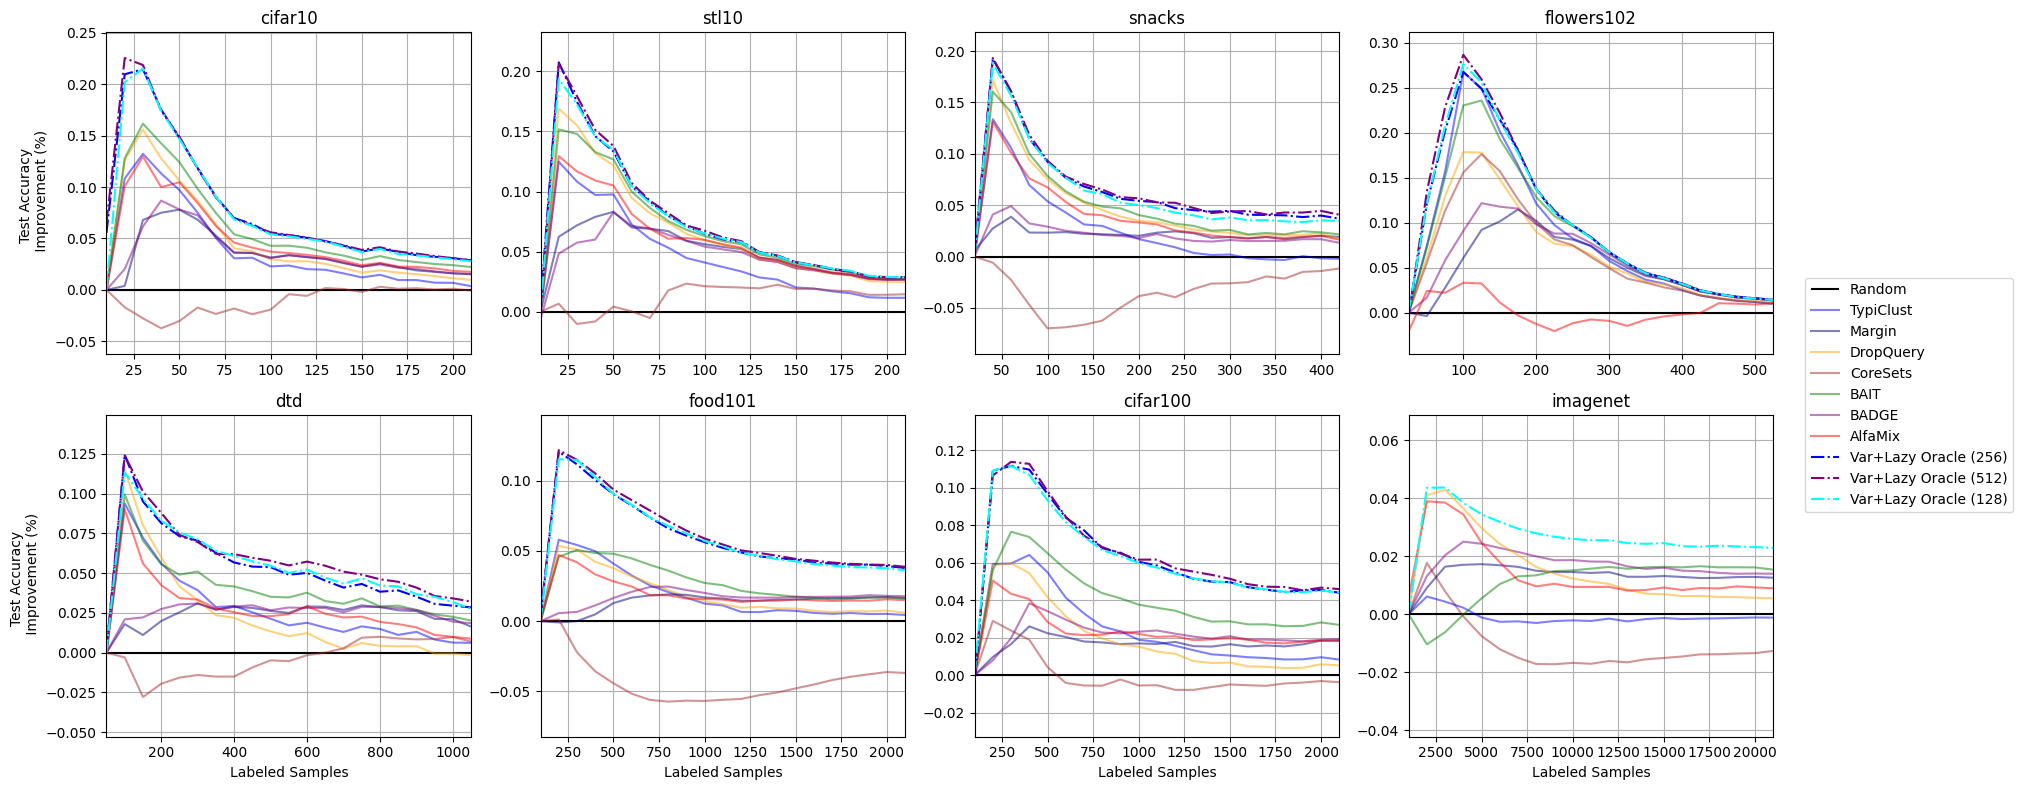

In [18]:
# To remove a query strategy from the plot, comment it out.
Q = {
    'alfamix' : {'c':'red', 'ls':'-', 'a':.5, 'n':'AlfaMix'},
    'badge' : {'c':'purple', 'ls':'-', 'a':.5, 'n':'BADGE'},
    'bait' : {'c':'green', 'ls':'-', 'a':.5, 'n':'BAIT'},
    'coreset' : {'c':'brown', 'ls':'-', 'a':.5, 'n':'CoreSets'},
    'dropquery' : {'c':'orange', 'ls':'-', 'a':.5, 'n':'DropQuery'},
    'margin' : {'c':'navy', 'ls':'-', 'a':.5, 'n':'Margin'},
    'typiclust' : {'c':'blue', 'ls':'-', 'a':.5, 'n':'TypiClust'},
   # 'base oracle 128' : {'c':'grey', 'ls':'-.', 'a':1, 'n':'Base Oracle (128)'},
   # 'lazy oracle 4' : {'c':'silver', 'ls':'--', 'a':1, 'n':'Lazy Oracle (4)'},
   # 'lazy oracle 128' : {'c':'silver', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (128)'},
    'var lazy oracle 128' : {'c':'cyan', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (128)'},
    'var lazy oracle 256' : {'c':'blue', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (256)'},
    'var lazy oracle 512' : {'c':'purple', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (512)'},
   # 'CrossDomainOracle' : {'c':'pink', 'ls':'-.', 'a':1, 'n':'CrossDomainOracle'}
}

fig, ax = plt.subplots(nrows=2, ncols=4, tight_layout=True, figsize=(18, 8))

for i, dset in enumerate(datasets):
    plt.axes(ax[i//4, i%4])
    acqs = datasets[dset]
    x_ticks = [i*acqs for i in range(1, 22)]

    plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles='-', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            values = np.mean(accs, axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, label=Q[strategy]['n'], c=Q[strategy]['c'], linestyle=Q[strategy]['ls'], alpha=Q[strategy]['a'])
    if i // 4 == 1:
        plt.xlabel('Labeled Samples')
    if i % 4 == 0:
        plt.ylabel('Test Accuracy \n Improvement (%)')
    plt.title(dset)
    plt.grid(True)
    plt.xlim((x_ticks[0], x_ticks[-1]))
    plt.ylim(ylim)
    if dset == 'cifar10':
        handles, labels = plt.gca().get_legend_handles_labels()
        
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

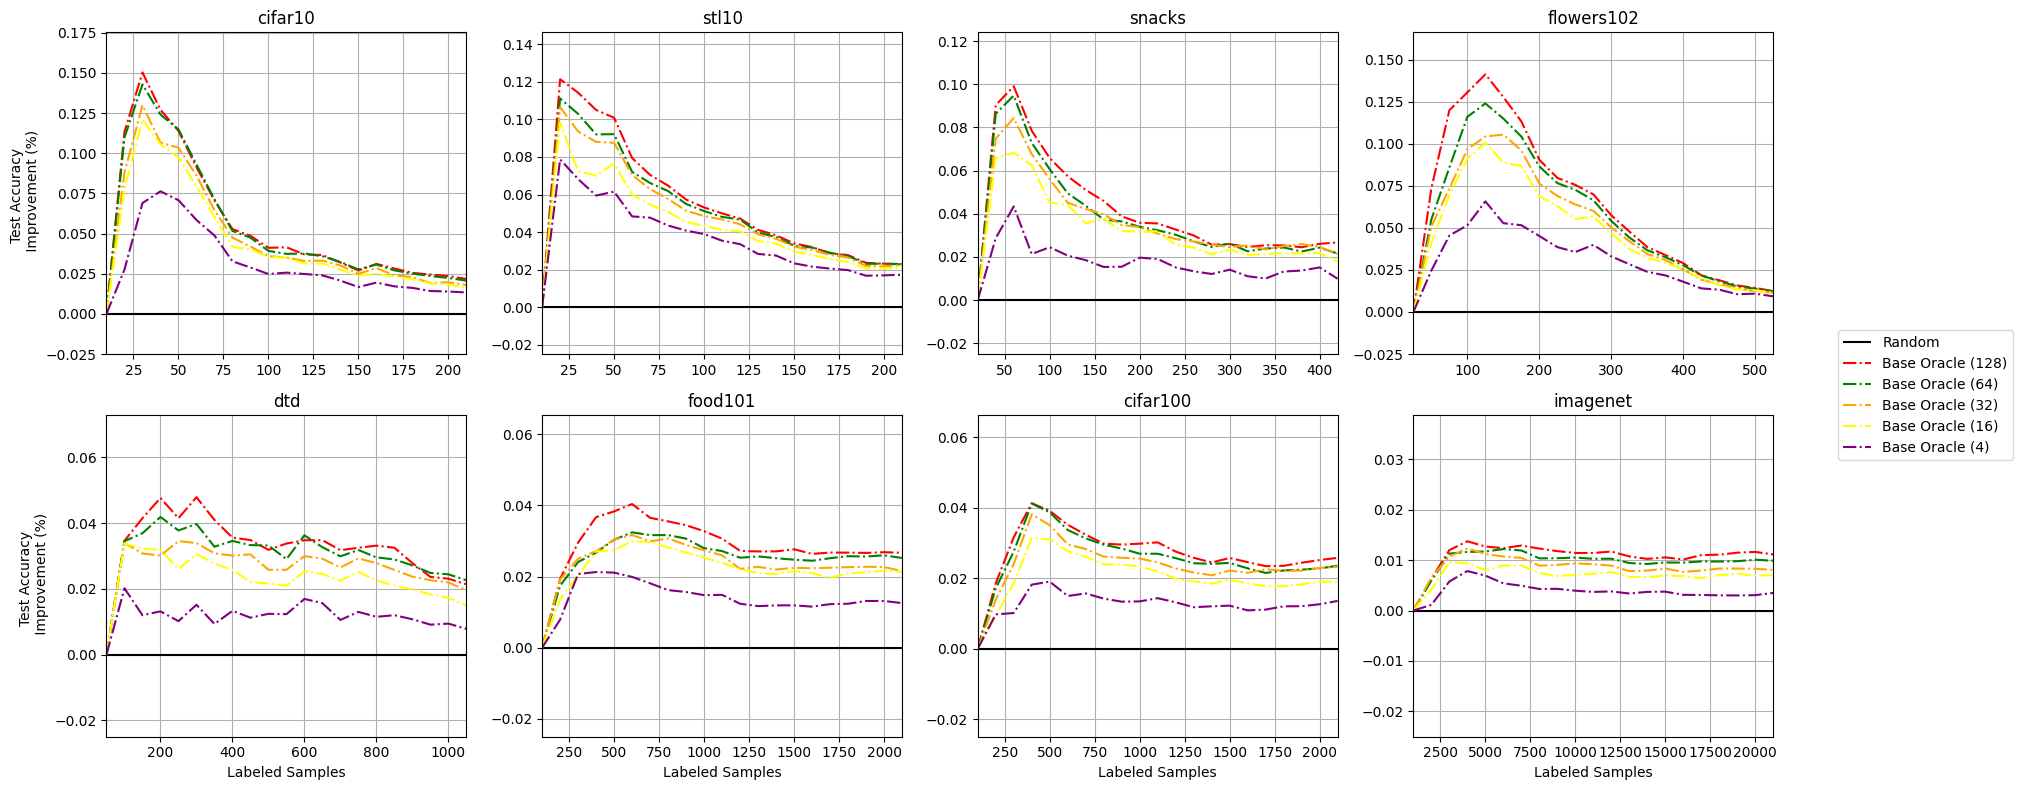

In [5]:
# To remove a query strategy from the plot, comment it out.
Q = {
    'base oracle 4' : {'c':'purple', 'ls':'-.', 'a':1, 'n':'Base Oracle (4)'},
    'base oracle 16' : {'c':'yellow', 'ls':'-.', 'a':1, 'n':'Base Oracle (16)'},
    'base oracle 32' : {'c':'orange', 'ls':'-.', 'a':1, 'n':'Base Oracle (32)'},
    'base oracle 64' : {'c':'green', 'ls':'-.', 'a':1, 'n':'Base Oracle (64)'},
    'base oracle 128' : {'c':'red', 'ls':'-.', 'a':1, 'n':'Base Oracle (128)'},
    'base oracle 256' : {'c':'cyan', 'ls':'-.', 'a':1, 'n':'Base Oracle (256)'},
    'base oracle 512' : {'c':'blue', 'ls':'-.', 'a':1, 'n':'Base Oracle (512)'},
}

fig, ax = plt.subplots(nrows=2, ncols=4, tight_layout=True, figsize=(18, 8))

for i, dset in enumerate(datasets):
    plt.axes(ax[i//4, i%4])
    acqs = datasets[dset]
    x_ticks = [i*acqs for i in range(1, 22)]

    plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles='-', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            values = np.mean(accs, axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, label=Q[strategy]['n'], c=Q[strategy]['c'], linestyle=Q[strategy]['ls'], alpha=Q[strategy]['a'])
    if i // 4 == 1:
        plt.xlabel('Labeled Samples')
    if i % 4 == 0:
        plt.ylabel('Test Accuracy \n Improvement (%)')
    plt.title(dset)
    plt.grid(True)
    plt.xlim((x_ticks[0], x_ticks[-1]))
    plt.ylim(ylim)
    if dset == 'cifar10':
        handles, labels = plt.gca().get_legend_handles_labels()
        
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

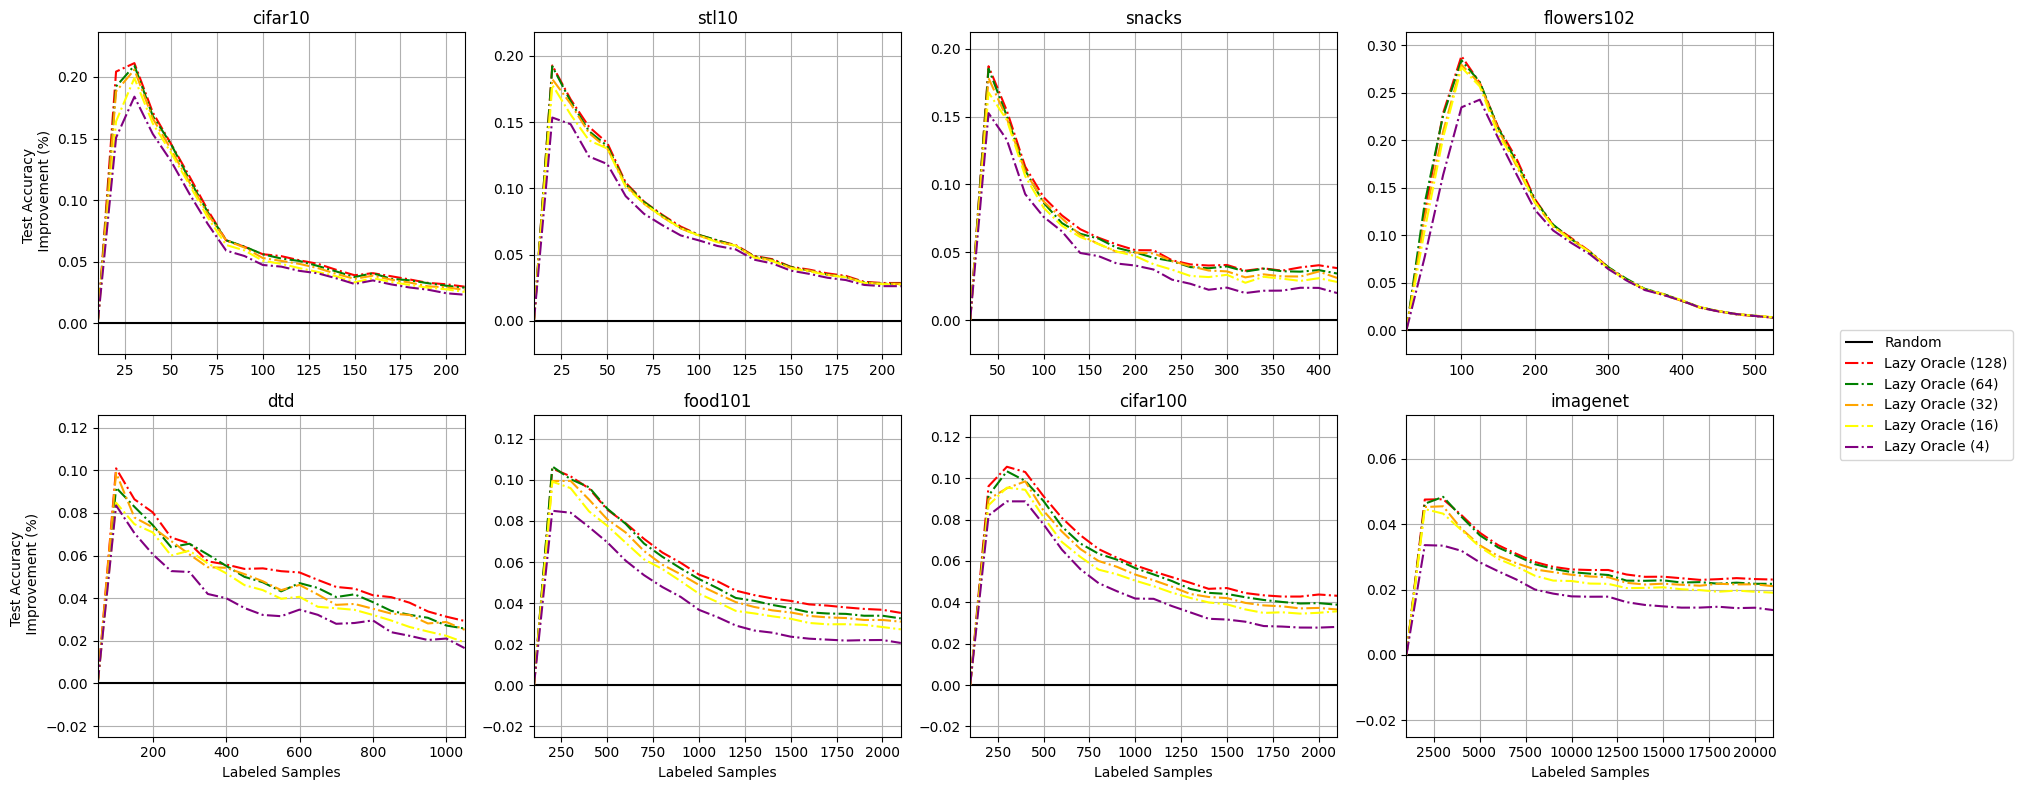

In [6]:
# To remove a query strategy from the plot, comment it out.
Q = {
    'lazy oracle 4' : {'c':'purple', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (4)'},
    'lazy oracle 16' : {'c':'yellow', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (16)'},
    'lazy oracle 32' : {'c':'orange', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (32)'},
    'lazy oracle 64' : {'c':'green', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (64)'},
    'lazy oracle 128' : {'c':'red', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (128)'},
    'lazy oracle 256' : {'c':'cyan', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (256)'},
    'lazy oracle 512' : {'c':'blue', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (512)'},
}

fig, ax = plt.subplots(nrows=2, ncols=4, tight_layout=True, figsize=(18, 8))

for i, dset in enumerate(datasets):
    plt.axes(ax[i//4, i%4])
    acqs = datasets[dset]
    x_ticks = [i*acqs for i in range(1, 22)]

    plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles='-', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            values = np.mean(accs, axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, label=Q[strategy]['n'], c=Q[strategy]['c'], linestyle=Q[strategy]['ls'], alpha=Q[strategy]['a'])
    if i // 4 == 1:
        plt.xlabel('Labeled Samples')
    if i % 4 == 0:
        plt.ylabel('Test Accuracy \n Improvement (%)')
    plt.title(dset)
    plt.grid(True)
    plt.xlim((x_ticks[0], x_ticks[-1]))
    plt.ylim(ylim)
    if dset == 'cifar10':
        handles, labels = plt.gca().get_legend_handles_labels()
        
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

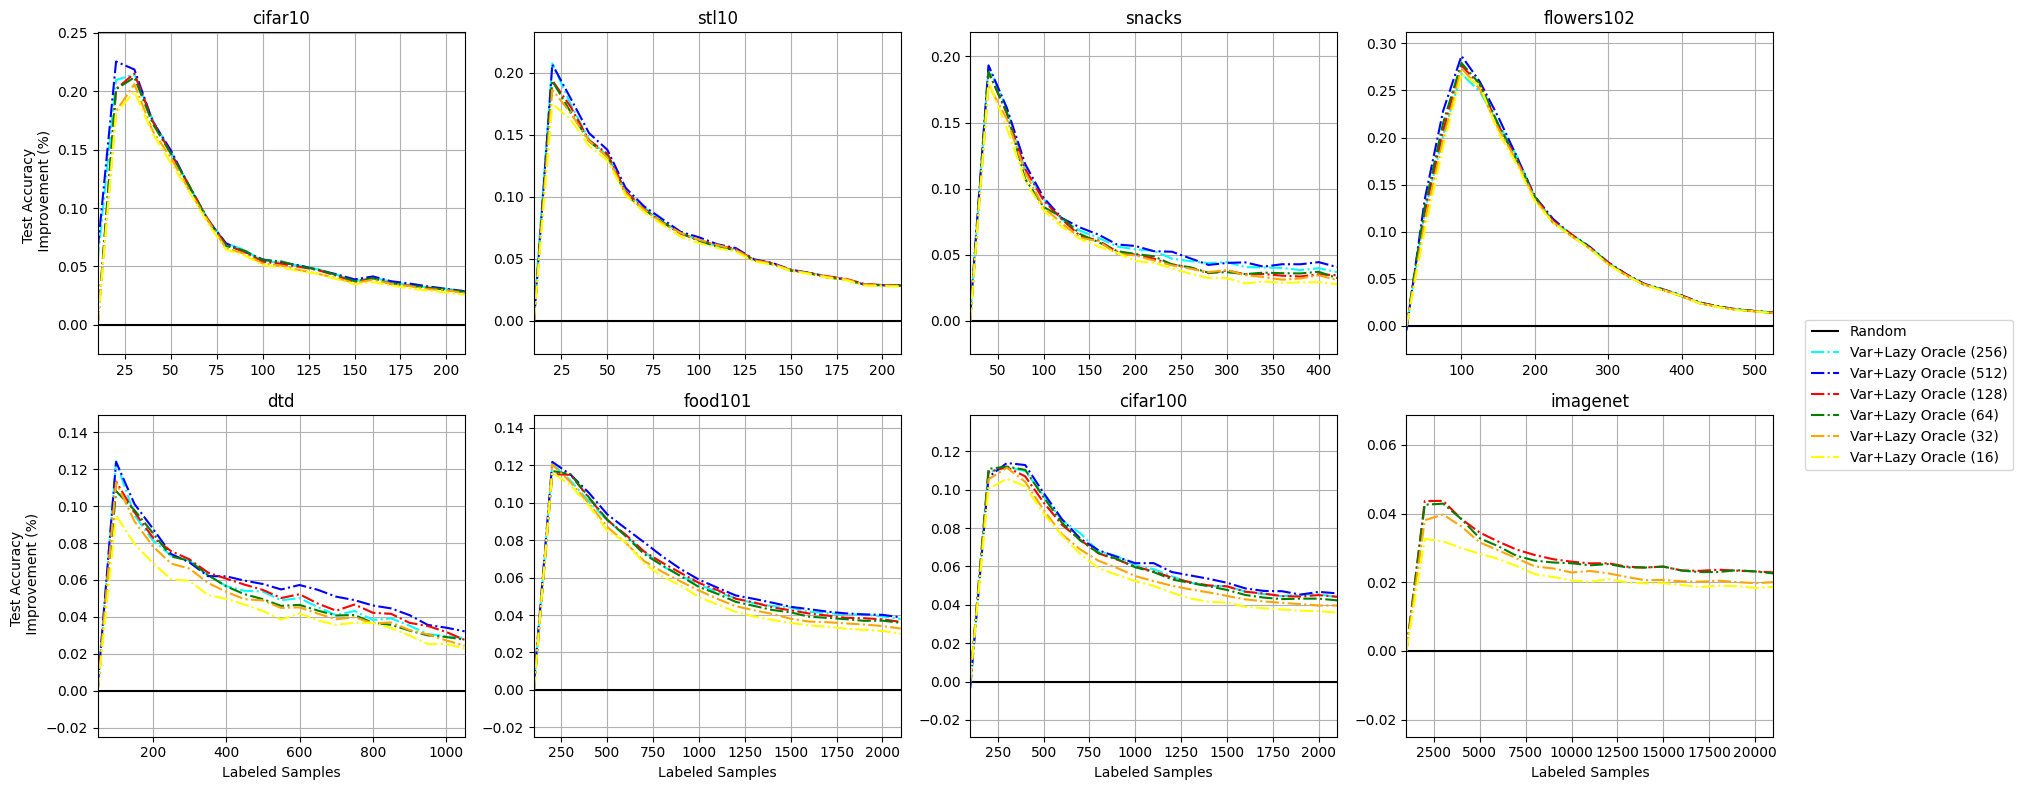

In [7]:
# To remove a query strategy from the plot, comment it out.
Q = {
    'var lazy oracle 16' : {'c':'yellow', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (16)'},
    'var lazy oracle 32' : {'c':'orange', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (32)'},
    'var lazy oracle 64' : {'c':'green', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (64)'},
    'var lazy oracle 128' : {'c':'red', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (128)'},
    'var lazy oracle 256' : {'c':'cyan', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (256)'},
    'var lazy oracle 512' : {'c':'blue', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (512)'},
}

fig, ax = plt.subplots(nrows=2, ncols=4, tight_layout=True, figsize=(18, 8))

for i, dset in enumerate(datasets):
    plt.axes(ax[i//4, i%4])
    acqs = datasets[dset]
    x_ticks = [i*acqs for i in range(1, 22)]

    plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles='-', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            values = np.mean(accs, axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, label=Q[strategy]['n'], c=Q[strategy]['c'], linestyle=Q[strategy]['ls'], alpha=Q[strategy]['a'])
    if i // 4 == 1:
        plt.xlabel('Labeled Samples')
    if i % 4 == 0:
        plt.ylabel('Test Accuracy \n Improvement (%)')
    plt.title(dset)
    plt.grid(True)
    plt.xlim((x_ticks[0], x_ticks[-1]))
    plt.ylim(ylim)
    if dset == 'cifar10':
        handles, labels = plt.gca().get_legend_handles_labels()
        
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

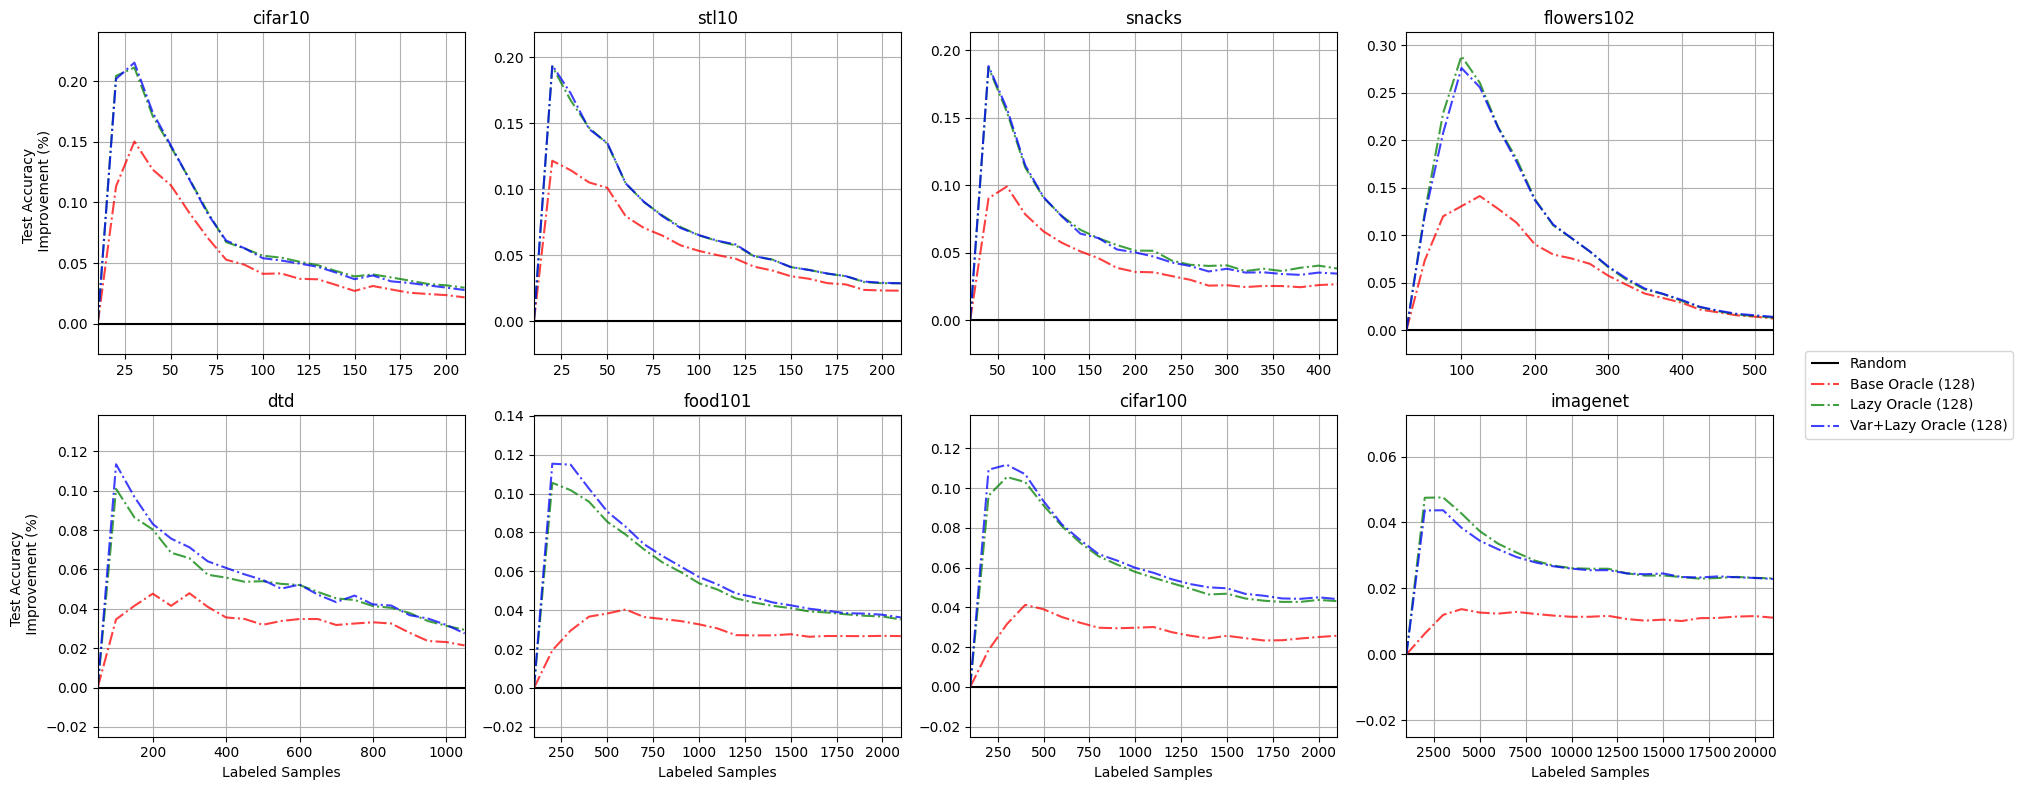

In [8]:
# To remove a query strategy from the plot, comment it out.
Q = {
    'var lazy oracle 128' : {'c':'blue', 'ls':'-.', 'a':.75, 'n':'Var+Lazy Oracle (128)'},
    'lazy oracle 128' : {'c':'green', 'ls':'-.', 'a':.75, 'n':'Lazy Oracle (128)'},
    'base oracle 128' : {'c':'red', 'ls':'-.', 'a':.75, 'n':'Base Oracle (128)'},
}

fig, ax = plt.subplots(nrows=2, ncols=4, tight_layout=True, figsize=(18, 8))

for i, dset in enumerate(datasets):
    plt.axes(ax[i//4, i%4])
    acqs = datasets[dset]
    x_ticks = [i*acqs for i in range(1, 22)]

    plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles='-', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            values = np.mean(accs, axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, label=Q[strategy]['n'], c=Q[strategy]['c'], linestyle=Q[strategy]['ls'], alpha=Q[strategy]['a'])
    if i // 4 == 1:
        plt.xlabel('Labeled Samples')
    if i % 4 == 0:
        plt.ylabel('Test Accuracy \n Improvement (%)')
    plt.title(dset)
    plt.grid(True)
    plt.xlim((x_ticks[0], x_ticks[-1]))
    plt.ylim(ylim)
    if dset == 'cifar10':
        handles, labels = plt.gca().get_legend_handles_labels()
        
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

In [9]:
Q = {
    'var lazy oracle 16' : {'c':'blue', 'ls':'--', 'a':.75, 'n':'Var+Lazy Oracle (16)'},
    'var lazy oracle 32' : {'c':'blue', 'ls':'--', 'a':.75, 'n':'Var+Lazy Oracle (32)'},
    'var lazy oracle 64' : {'c':'blue', 'ls':'--', 'a':.75, 'n':'Var+Lazy Oracle (64)'},
    'var lazy oracle 128' : {'c':'blue', 'ls':':', 'a':.75, 'n':'Var+Lazy Oracle (128)'},
    'var lazy oracle 512' : {'c':'blue', 'ls':'-.', 'a':.75, 'n':'Var+Lazy Oracle (512)'},
    'lazy oracle 4' : {'c':'green', 'ls':'--', 'a':.75, 'n':'Lazy Oracle (4)'},
    'lazy oracle 16' : {'c':'green', 'ls':'--', 'a':.75, 'n':'Lazy Oracle (16)'},
    'lazy oracle 32' : {'c':'green', 'ls':'--', 'a':.75, 'n':'Lazy Oracle (32)'},
    'lazy oracle 64' : {'c':'green', 'ls':'--', 'a':.75, 'n':'Lazy Oracle (64)'},
    'lazy oracle 128' : {'c':'green', 'ls':':', 'a':.75, 'n':'Lazy Oracle (128)'},
    'lazy oracle 512' : {'c':'green', 'ls':'-.', 'a':.75, 'n':'Lazy Oracle (512)'},
    'base oracle 32' : {'c':'red', 'ls':'--', 'a':.75, 'n':'Base Oracle (32)'},
    'base oracle 128' : {'c':'red', 'ls':':', 'a':.75, 'n':'Base Oracle (128)'},
    'base oracle 512' : {'c':'red', 'ls':'-.', 'a':.75, 'n':'Base Oracle (512)'},
    'CrossDomainOracle' : {'c':'pink', 'ls':'-.', 'a':1, 'n':'CrossDomainOracle'}
}

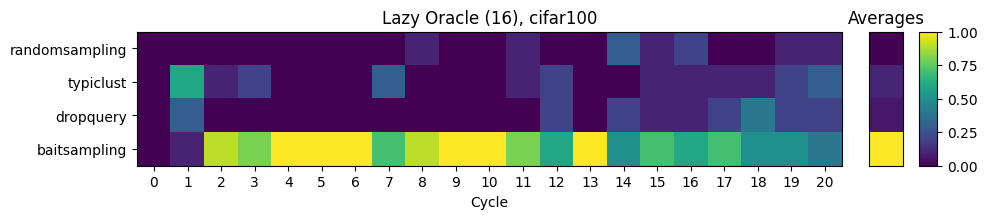

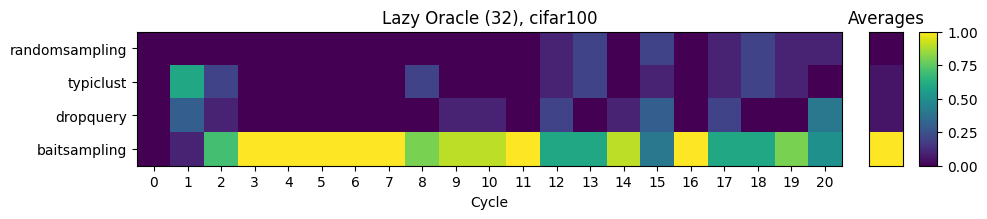

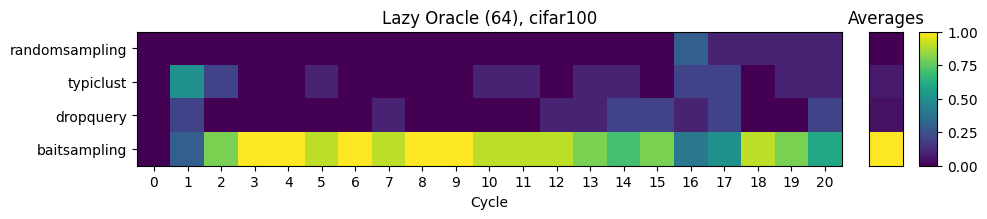

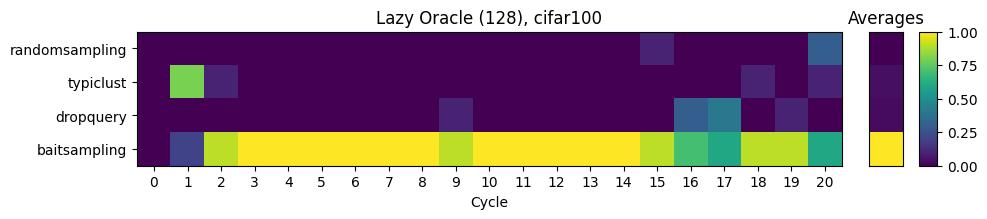

In [10]:
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling']
cmap = 'viridis'
dset = 'cifar100'
query_size = datasets[dset]
n_queries = 21

for strat in ['lazy oracle 16', 'lazy oracle 32', 'lazy oracle 64', 'lazy oracle 128']:
    fig, ax = plt.subplots(nrows=1, ncols=3, width_ratios=[20, 1, .5], figsize=(10, 2))

    image = []
    for sampl_strat in sampling_strategies:
        img = []
        for seed in range(10):
            if len(all_pick_choices[dset][strat]) > seed:
                im = []
                for i in range(n_queries):
                    if i == 0:
                        im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                    else:
                        im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                img.append(im)
        image.append(img)
    image_arr = np.array(image)
    pick_choices = np.mean(image_arr, axis=1)
    avg_pick_choices = np.mean(pick_choices, axis=-1, keepdims=True)

    cax1 = ax[0].imshow(pick_choices)
    ax[0].set_xlabel('Cycle')
    ax[0].set_xticks(range(n_queries))
    ax[0].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
    ax[0].set_title(Q[strat]['n']+', '+dset)

    ax[1].imshow(avg_pick_choices)
    ax[1].set_title('Averages')
    ax[1].set_xticks([])
    ax[1].set_yticks([])

    cbar = fig.colorbar(cax1, cax=ax[2], orientation='vertical')
    plt.tight_layout()
    plt.show()

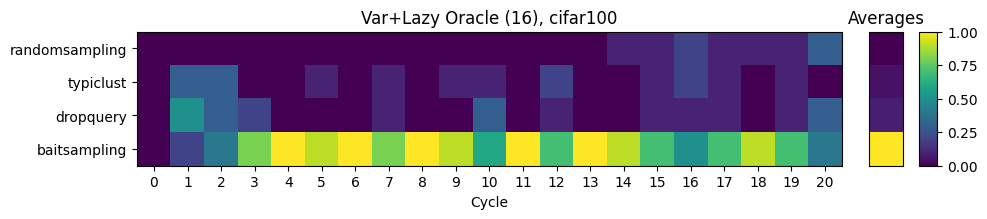

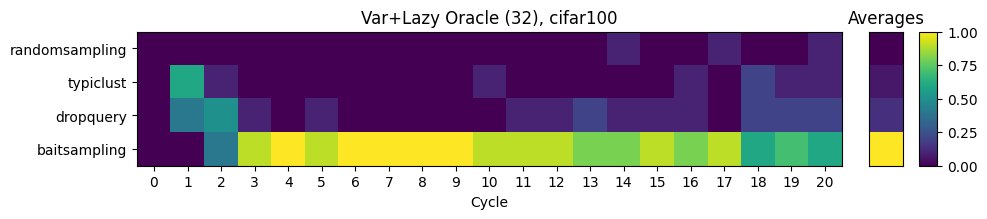

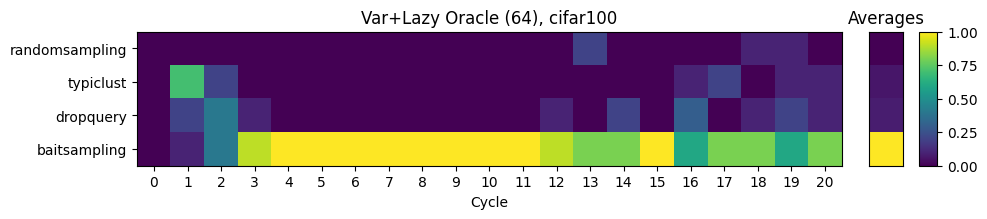

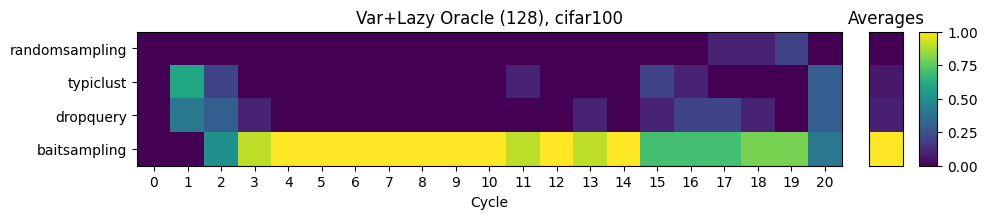

In [11]:
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling']
cmap = 'viridis'
dset = 'cifar100'
query_size = datasets[dset]
n_queries = 21

for strat in ['var lazy oracle 16', 'var lazy oracle 32', 'var lazy oracle 64', 'var lazy oracle 128']:
    fig, ax = plt.subplots(nrows=1, ncols=3, width_ratios=[20, 1, .5], figsize=(10, 2))

    image = []
    for sampl_strat in sampling_strategies:
        img = []
        for seed in range(10):
            if len(all_pick_choices[dset][strat]) > seed:
                im = []
                for i in range(n_queries):
                    if i == 0:
                        im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                    else:
                        im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                img.append(im)
        image.append(img)
    image_arr = np.array(image)
    pick_choices = np.mean(image_arr, axis=1)
    avg_pick_choices = np.mean(pick_choices, axis=-1, keepdims=True)

    cax1 = ax[0].imshow(pick_choices)
    ax[0].set_xlabel('Cycle')
    ax[0].set_xticks(range(n_queries))
    ax[0].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
    ax[0].set_title(Q[strat]['n']+', '+dset)

    ax[1].imshow(avg_pick_choices)
    ax[1].set_title('Averages')
    ax[1].set_xticks([])
    ax[1].set_yticks([])

    cbar = fig.colorbar(cax1, cax=ax[2], orientation='vertical')
    plt.tight_layout()
    plt.show()

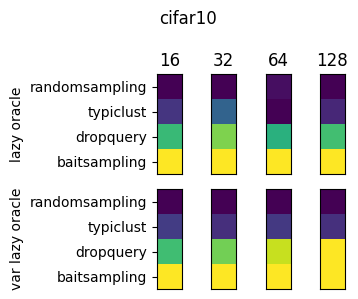

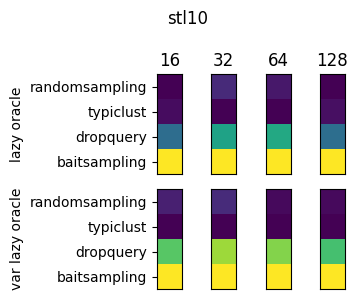

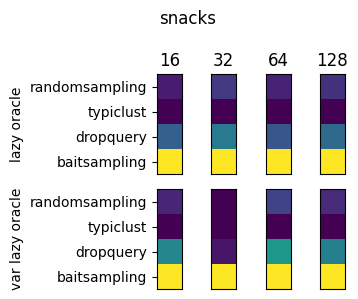

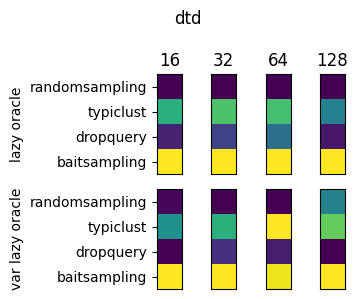

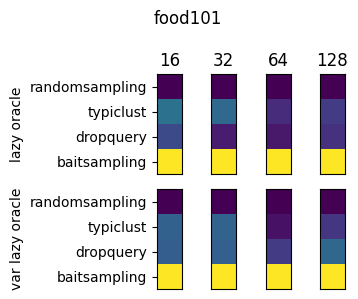

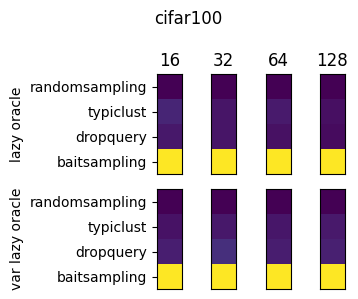

In [12]:
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling']
cmap = 'viridis'
n_queries = 21

for dset in datasets:
    if dset not in ['flowers102', 'imagenet']: # TODO: To be done after their experiments finished
        fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(4, 3))
        fig.suptitle(dset)
        query_size = datasets[dset]
        for j, bs in enumerate(['16', '32', '64', '128']):
            for k, strategy in enumerate(['lazy oracle', 'var lazy oracle']):
                strat = strategy + ' ' + bs
                image = []
                for sampl_strat in sampling_strategies:
                    img = []
                    for seed in range(10):
                        im = []
                        if seed < len(all_pick_choices[dset][strat]):
                            for i in range(n_queries):
                                if i == 0:
                                    im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                                else:
                                    im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                            img.append(im)
                    image.append(img)
                image = np.array(image)
                img = np.mean(image, axis=1)
                img_avg = np.mean(img, axis=-1, keepdims=True)

                ax[k][j].imshow(img_avg)
                ax[k][j].set_xticks([])
                if j == 0:
                    ax[k][j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
                else:
                    ax[k][j].set_yticks([])

                if j == 0:
                    ax[k][j].set_ylabel(strategy)
                if k == 0:
                    ax[k][j].set_title(bs)

        plt.tight_layout()
        plt.show()

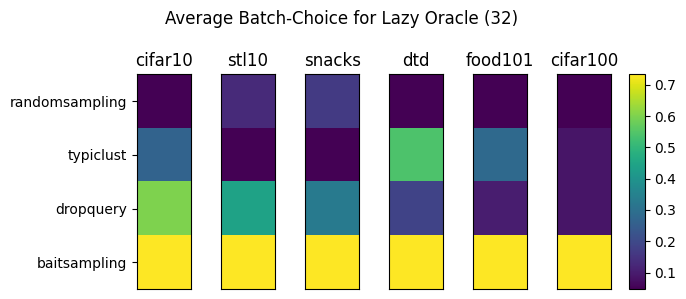

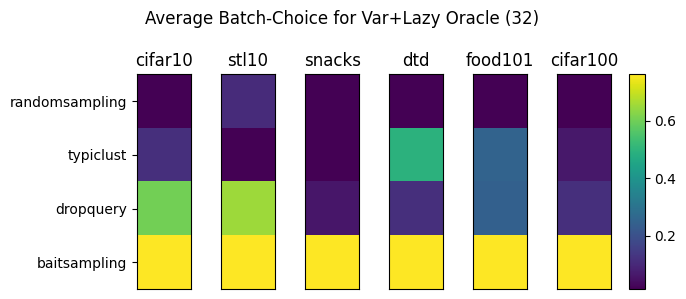

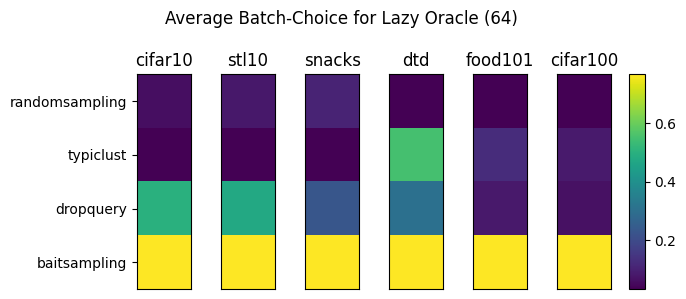

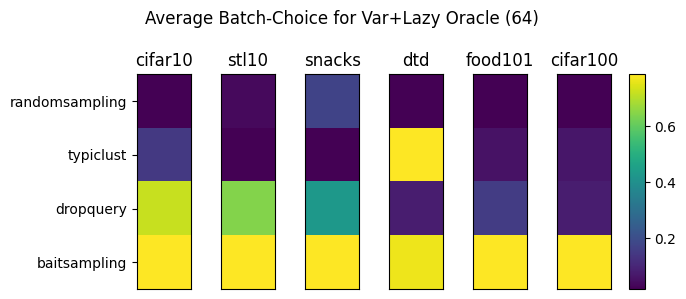

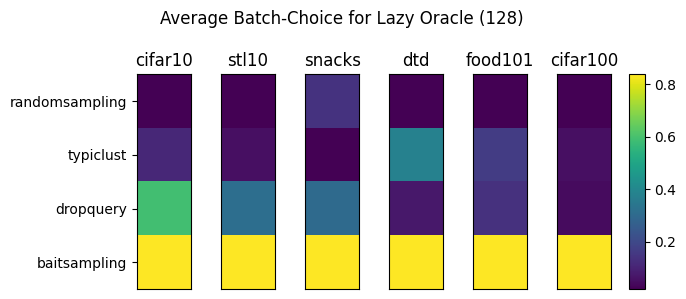

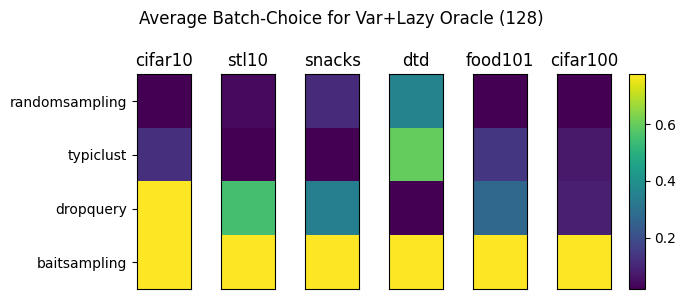

In [16]:
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling']
cmap = 'viridis'
n_queries = 21

for strat in ['lazy oracle 32', 'var lazy oracle 32', 'lazy oracle 64', 'var lazy oracle 64', 'lazy oracle 128', 'var lazy oracle 128']:
    fig, ax = plt.subplots(nrows=1, ncols=7, figsize=(7, 3), width_ratios=[1, 1, 1, 1, 1, 1, .2])
    fig.suptitle("Average Batch-Choice for "+Q[strat]['n'])
    j = 0
    for dset in datasets:
        if dset not in ['flowers102', 'imagenet']: # TODO: To be done after their experiments finished
            query_size = datasets[dset]
            image = []
            for sampl_strat in sampling_strategies:
                img = []
                for seed in range(10):
                    im = []
                    if seed < len(all_pick_choices[dset][strat]):
                        for i in range(n_queries):
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        img.append(im)
                image.append(img)
            image = np.array(image)
            img = np.mean(image, axis=1)
            img_avg = np.mean(img, axis=-1, keepdims=True)

            c1 = ax[j].imshow(img_avg)
            ax[j].set_xticks([])
            if j == 0:
                ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
            else:
                ax[j].set_yticks([])
            ax[j].set_title(dset)

            j += 1

    fig.colorbar(c1, cax=ax[-1])
    plt.tight_layout()
    plt.show()

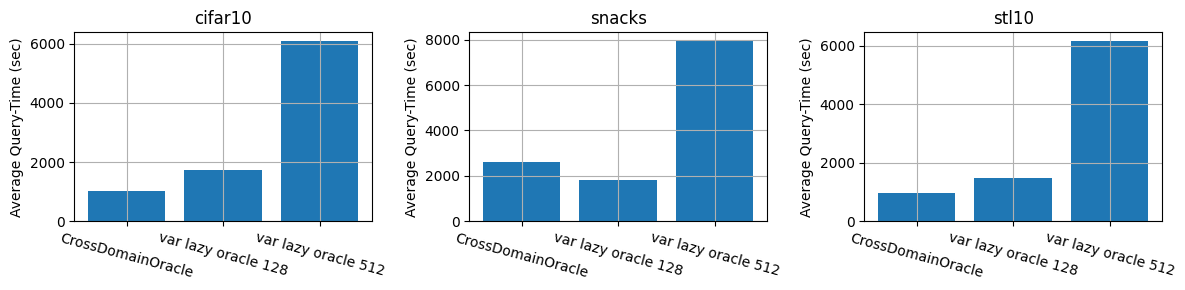

In [14]:
# Time Comparison
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,3), tight_layout=True)

for i, dset in enumerate(['cifar10', 'snacks', 'stl10']):
    plt.axes(ax[i])
    D = {}
    for strat in ['CrossDomainOracle', 'var lazy oracle 128', 'var lazy oracle 512']:
        qts = np.sum(np.mean(query_times[dset][strat], axis=0))
        D[strat] = qts
    plt.bar(range(len(D)), list(D.values()), align='center')
    plt.xticks(ticks=range(len(D)), labels=list(D.keys()), rotation=345)
    plt.title(dset)
    plt.ylabel('Average Query-Time (sec)')
    plt.grid(True)
    
plt.show()